---
# PARTIE 1 — Exploration et Préparation des Données

## 1.1 Importation des bibliothèques

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid', palette='Set2')
print('Bibliothèques importées avec succès !')

Bibliothèques importées avec succès !


## 1.2 Chargement du dataset

In [32]:
df = pd.read_csv('projet1.csv')
print(f'Dimensions du dataset : {df.shape}')
print(f'Nombre de lignes : {df.shape[0]}')
print(f'Nombre de colonnes : {df.shape[1]}')
df.head(10)

Dimensions du dataset : (26052, 7)
Nombre de lignes : 26052
Nombre de colonnes : 7


,index,City,Date,Card Type,Exp Type,Gender,Amount
0,0,NaN,29-Oct-14,Gold,Bills,NaN,82475
1,1,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,2,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,4,"Bengaluru, India",5-May-15,Gold,Bills,NaN,171574
5,5,"Delhi, India",8-Sep-14,Silver,Bills,F,100036
6,6,"Delhi, India",24-Feb-15,Gold,Bills,F,143250
7,7,"Greater Mumbai, India",26-Jun-14,NaN,Bills,F,150980
8,8,"Delhi, India",28-Mar-14,NaN,Bills,F,192247
9,9,"Delhi, India",1-Sep-14,Platinum,Bills,F,67932


## 1.3 Analyse Exploratoire des Données (EDA)

### 1.3.1 Informations générales sur le dataset

In [33]:
print('=== Informations générales ===')
df.info()

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   index      26052 non-null  int64
 1   City       24241 non-null  str  
 2   Date       26052 non-null  str  
 3   Card Type  24223 non-null  str  
 4   Exp Type   26052 non-null  str  
 5   Gender     24208 non-null  str  
 6   Amount     26052 non-null  int64
dtypes: int64(2), str(5)
memory usage: 1.4 MB


In [34]:
print('=== Statistiques descriptives ===')
df.describe(include='all')

=== Statistiques descriptives ===


,index,City,Date,Card Type,Exp Type,Gender,Amount
count,26052.000000,24241,26052,24223,26052,24208,26052.000000
unique,NaN,983,600,4,6,2,NaN
top,NaN,"Bengaluru, India",20-Sep-14,Silver,Food,F,NaN
freq,NaN,3290,65,6405,5463,12709,NaN
mean,13025.500000,NaN,NaN,NaN,NaN,NaN,156411.537425
std,7520.708943,NaN,NaN,NaN,NaN,NaN,103063.254287
min,0.000000,NaN,NaN,NaN,NaN,NaN,1005.000000
25%,6512.750000,NaN,NaN,NaN,NaN,NaN,77120.250000
50%,13025.500000,NaN,NaN,NaN,NaN,NaN,153106.500000
75%,19538.250000,NaN,NaN,NaN,NaN,NaN,228050.000000


### 1.3.2 Analyse des valeurs manquantes

=== Valeurs manquantes par colonne ===
           Valeurs manquantes  Pourcentage (%)
City                     1811             6.95
Card Type                1829             7.02
Gender                   1844             7.08


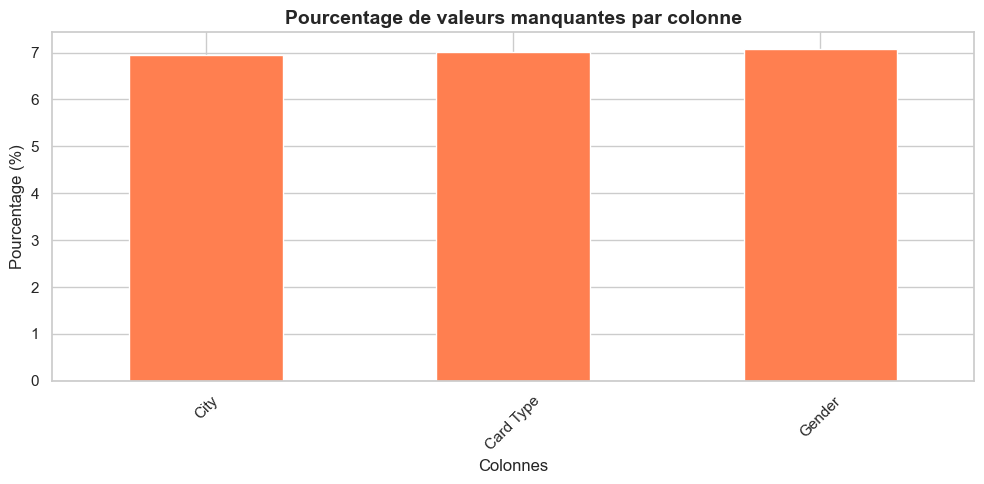

In [35]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct.round(2)})
print('=== Valeurs manquantes par colonne ===')
print(missing_df[missing_df['Valeurs manquantes'] > 0])

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind='bar', color='coral', ax=ax)
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=14, fontweight='bold')
ax.set_ylabel('Pourcentage (%)')
ax.set_xlabel('Colonnes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3.3 Distribution des variables catégorielles

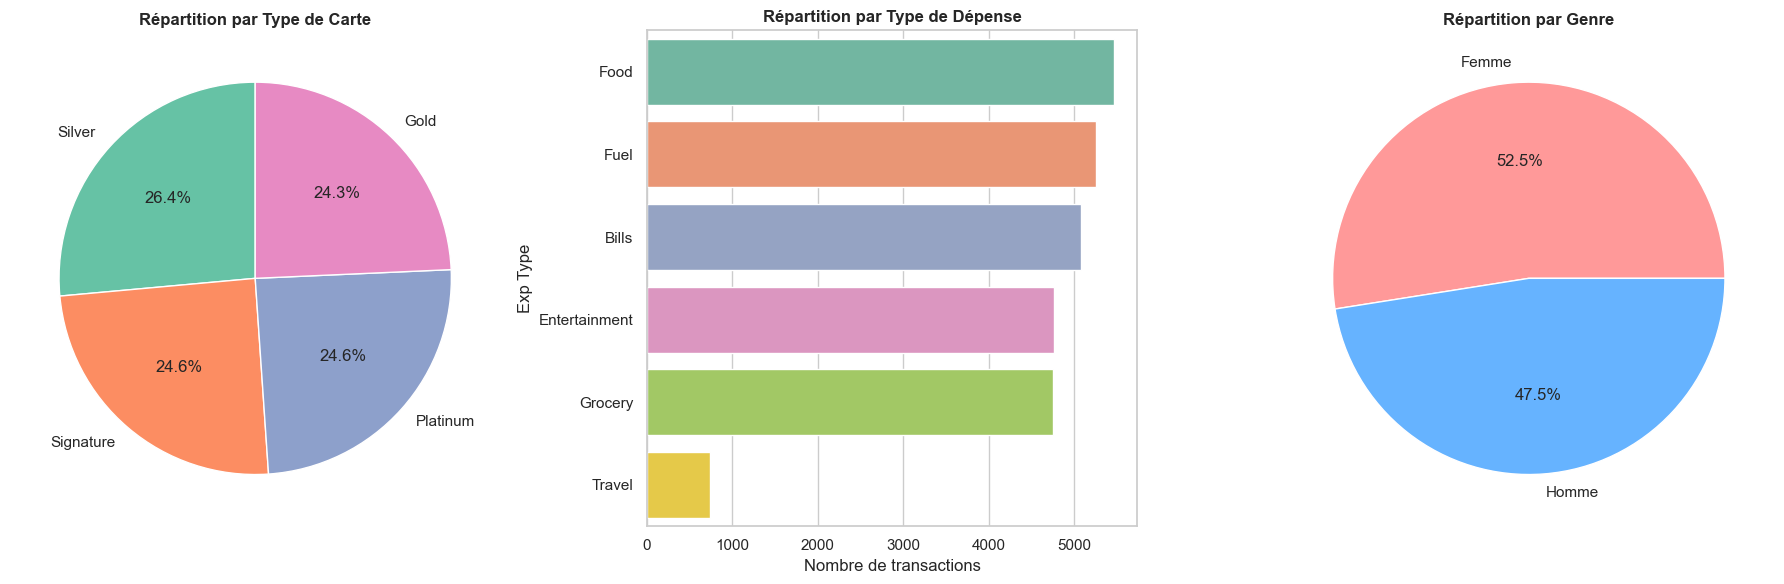

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Card Type
card_counts = df['Card Type'].value_counts()
axes[0].pie(card_counts, labels=card_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Répartition par Type de Carte', fontweight='bold')

# Exp Type
exp_counts = df['Exp Type'].value_counts()
sns.barplot(x=exp_counts.values, y=exp_counts.index, ax=axes[1], palette='Set2')
axes[1].set_title('Répartition par Type de Dépense', fontweight='bold')
axes[1].set_xlabel('Nombre de transactions')

# Gender
gender_counts = df['Gender'].value_counts()
axes[2].pie(gender_counts, labels=['Femme', 'Homme'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
axes[2].set_title('Répartition par Genre', fontweight='bold')

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3.4 Distribution de la variable Amount

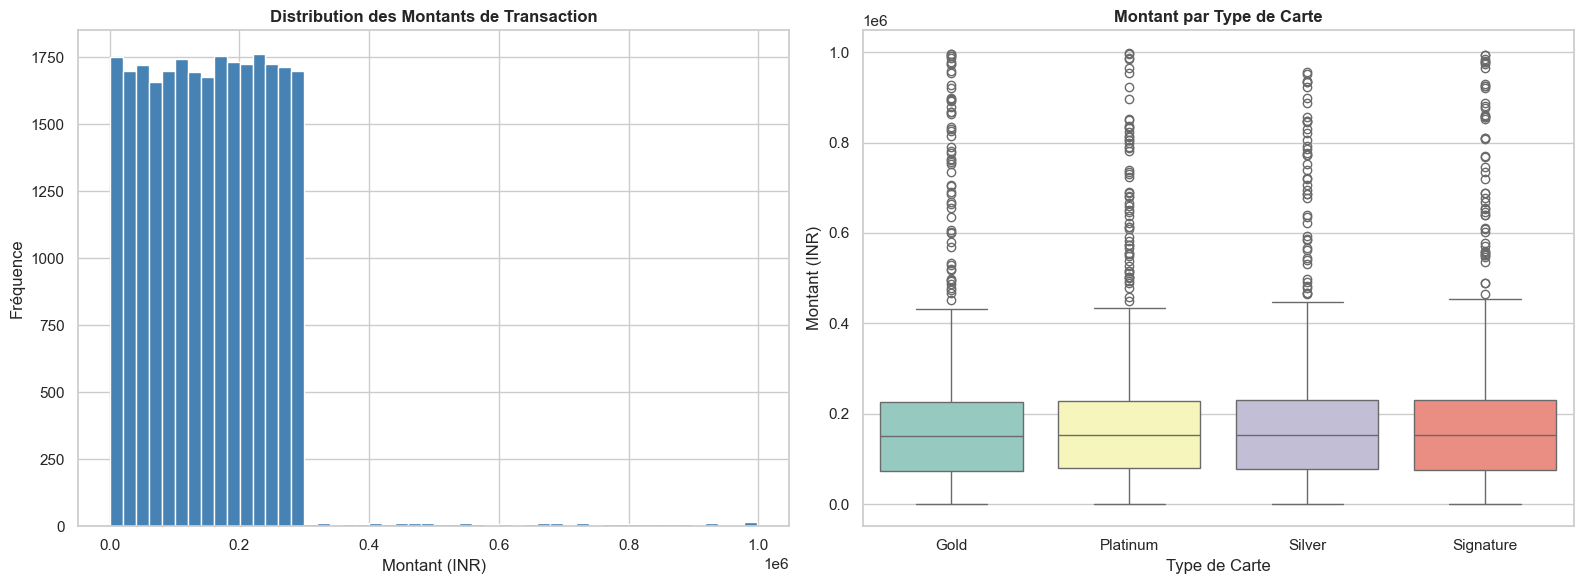

Montant moyen   : 156,412 INR
Montant médian  : 153,106 INR
Montant min     : 1,005 INR
Montant max     : 998,077 INR


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme
axes[0].hist(df['Amount'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des Montants de Transaction', fontweight='bold')
axes[0].set_xlabel('Montant (INR)')
axes[0].set_ylabel('Fréquence')

# Boxplot par Card Type
df_clean_temp = df.dropna(subset=['Card Type', 'Amount'])
sns.boxplot(x='Card Type', y='Amount', data=df_clean_temp, ax=axes[1], palette='Set3')
axes[1].set_title('Montant par Type de Carte', fontweight='bold')
axes[1].set_xlabel('Type de Carte')
axes[1].set_ylabel('Montant (INR)')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Montant moyen   : {df["Amount"].mean():,.0f} INR')
print(f'Montant médian  : {df["Amount"].median():,.0f} INR')
print(f'Montant min     : {df["Amount"].min():,.0f} INR')
print(f'Montant max     : {df["Amount"].max():,.0f} INR')

### 1.3.5 Analyse temporelle

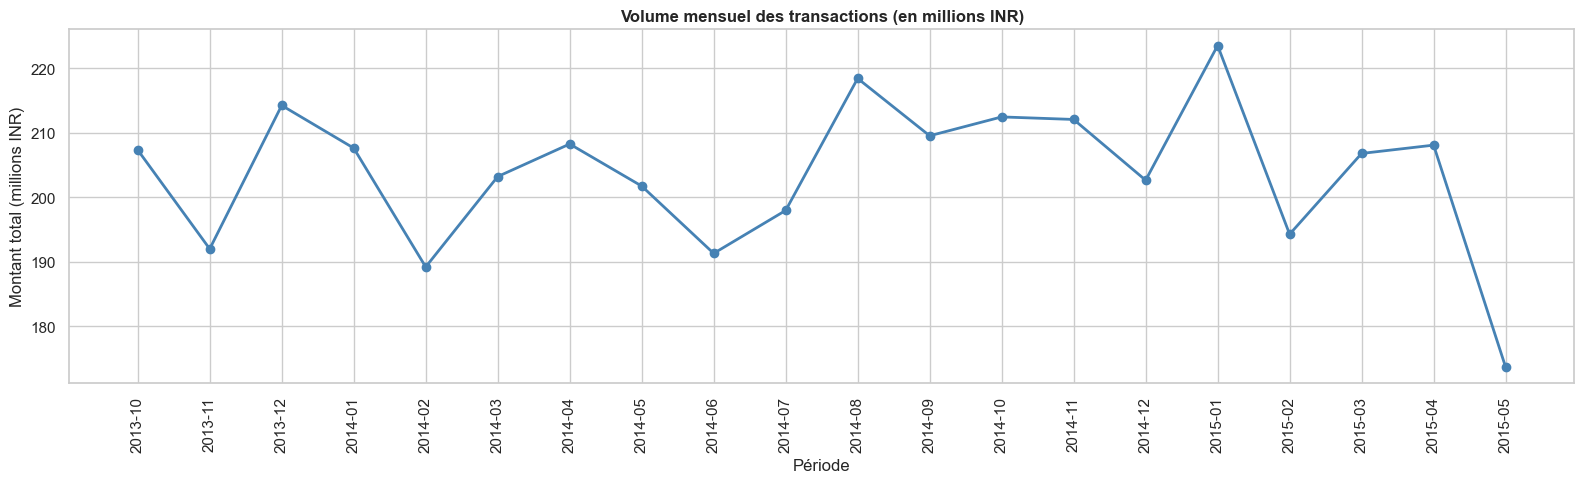

In [38]:
df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year']  = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month

monthly = df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

plt.figure(figsize=(16, 5))
plt.plot(monthly['Period'], monthly['Amount'] / 1e6, marker='o', color='steelblue', linewidth=2)
plt.title('Volume mensuel des transactions (en millions INR)', fontweight='bold')
plt.xlabel('Période')
plt.ylabel('Montant total (millions INR)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3.6 Top 10 villes par volume de transactions

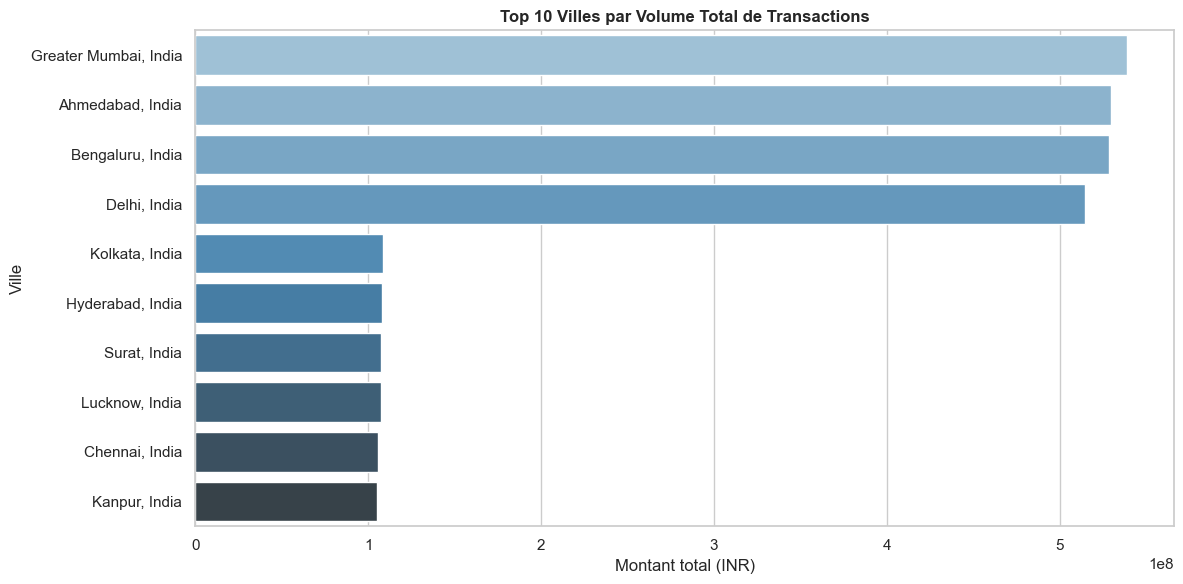

In [39]:
top_cities = df.groupby('City')['Amount'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Amount', y='City', data=top_cities, palette='Blues_d')
plt.title('Top 10 Villes par Volume Total de Transactions', fontweight='bold')
plt.xlabel('Montant total (INR)')
plt.ylabel('Ville')
plt.tight_layout()
plt.savefig('top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3.7 Heatmap — Montant moyen par Type de Carte et Type de Dépense

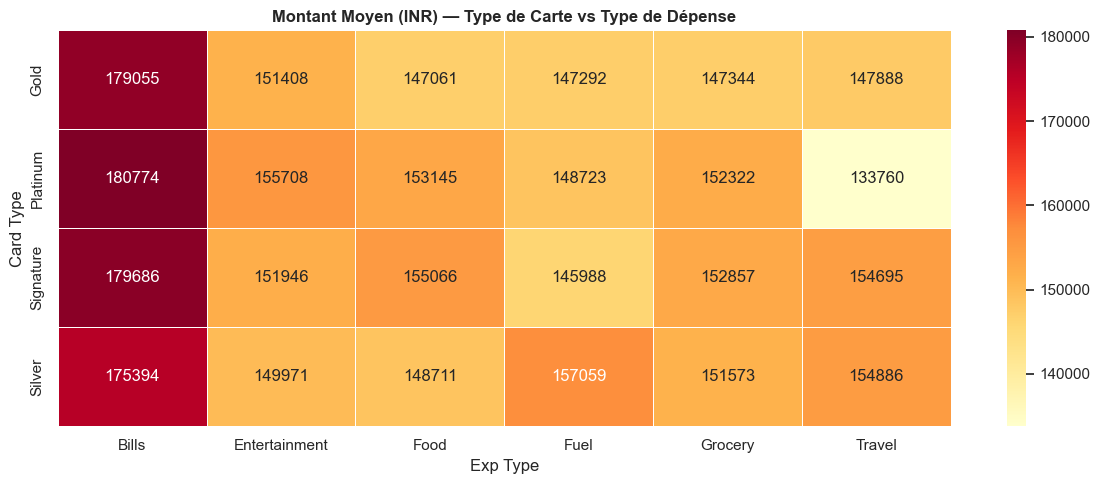

In [40]:
pivot = df.pivot_table(values='Amount', index='Card Type', columns='Exp Type', aggfunc='mean')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Montant Moyen (INR) — Type de Carte vs Type de Dépense', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_card_exp.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.4 Nettoyage des Données

**Justification des choix :**
- **Valeurs manquantes** : Les colonnes `City`, `Card Type` et `Gender` contiennent ~7% de valeurs manquantes. Nous supprimons ces lignes car elles représentent une proportion faible et les valeurs manquantes sont probablement aléatoires (MCAR).
- **Doublons** : Vérification et suppression des lignes identiques.
- **Colonne `index`** : Redondante avec l'index pandas, elle est supprimée.
- **Outliers** : Nous conservons les valeurs extrêmes car elles représentent de vraies transactions (pas des erreurs de saisie).

In [41]:
print(f'Taille initiale : {df.shape}')

# Supprimer la colonne index redondante
df_clean = df.drop(columns=['index'])

# Supprimer les doublons
nb_doublons = df_clean.duplicated().sum()
print(f'Doublons détectés : {nb_doublons}')
df_clean = df_clean.drop_duplicates()

# Supprimer les lignes avec valeurs manquantes dans les colonnes critiques
cols_critiques = ['City', 'Card Type', 'Gender']
avant = len(df_clean)
df_clean = df_clean.dropna(subset=cols_critiques)
apres = len(df_clean)
print(f'Lignes supprimées (valeurs manquantes) : {avant - apres}')

# Nettoyage des chaînes de caractères
df_clean['City'] = df_clean['City'].str.strip()
df_clean['Card Type'] = df_clean['Card Type'].str.strip()
df_clean['Exp Type'] = df_clean['Exp Type'].str.strip()
df_clean['Gender'] = df_clean['Gender'].str.strip().str.upper()

# Conversion de la date
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, errors='coerce')
df_clean['Year']  = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month

print(f'Taille après nettoyage : {df_clean.shape}')
print(f'\nValeurs manquantes restantes :')
print(df_clean.isnull().sum())

Taille initiale : (26052, 10)
Doublons détectés : 0
Lignes supprimées (valeurs manquantes) : 5108
Taille après nettoyage : (20944, 9)

Valeurs manquantes restantes :
City           0
Date           0
Card Type      0
Exp Type       0
Gender         0
Amount         0
Date_parsed    0
Year           0
Month          0
dtype: int64


## 1.5 Prétraitement des Données

**Techniques appliquées :**
1. **Encodage des variables catégorielles** : Label Encoding pour `Card Type`, `Exp Type`, `Gender` — adapté au clustering
2. **Extraction de features temporelles** : `Year`, `Month` depuis `Date`
3. **Standardisation** : StandardScaler (moyenne=0, écart-type=1) pour que toutes les variables aient le même poids dans le clustering

In [42]:
df_model = df_clean.copy()

# Encodage Label Encoding
le = LabelEncoder()
for col in ['Card Type', 'Exp Type', 'Gender']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    print(f'{col} → {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Sélection des features pour le clustering
features = ['Amount', 'Card Type_enc', 'Exp Type_enc', 'Gender_enc', 'Month', 'Year']
X = df_model[features].copy()

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print(f'\nDimension des données prétraitées : {X_scaled.shape}')
print('\nAperçu des données standardisées :')
X_scaled_df.head()

Card Type → {'Gold': np.int64(0), 'Platinum': np.int64(1), 'Signature': np.int64(2), 'Silver': np.int64(3)}
Exp Type → {'Bills': np.int64(0), 'Entertainment': np.int64(1), 'Food': np.int64(2), 'Fuel': np.int64(3), 'Grocery': np.int64(4), 'Travel': np.int64(5)}
Gender → {'F': np.int64(0), 'M': np.int64(1)}

Dimension des données prétraitées : (20944, 6)

Aperçu des données standardisées :


,Amount,Card Type_enc,Exp Type_enc,Gender_enc,Month,Year
0,-1.203568,-0.474715,-1.420892,-0.947245,0.439040,-0.149368
1,-0.531987,1.303577,-1.420892,-0.947245,0.439040,-0.149368
2,-0.321474,0.414431,-1.420892,-0.947245,-0.630362,-0.149368
3,-0.548509,1.303577,-1.420892,-0.947245,0.706390,-0.149368
4,-0.129017,-1.363861,-1.420892,-0.947245,-1.165062,1.463192


In [ ]:
# Visualisation de la distribution après standardisation
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(X_scaled_df[feat], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution : {feat}', fontweight='bold')
    axes[i].set_xlabel('Valeur standardisée')

plt.suptitle('Distribution des Features après Standardisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTIE 2 — Clustering

## 2.1 K-Means Clustering

### 2.1.1 Détermination du nombre optimal de clusters

Nous utilisons deux méthodes complémentaires :
- **Méthode du Coude (Elbow)** : minimiser l'inertie (WCSS — Within Cluster Sum of Squares)
- **Score de Silhouette** : mesurer la cohésion et la séparation des clusters (valeur entre -1 et 1, plus proche de 1 = mieux)

In [ ]:
# Sous-échantillonnage pour accélérer le calcul
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, labels))
    print(f'k={k} | Inertie={kmeans.inertia_:.0f} | Silhouette={silhouette_score(X_sample, labels):.4f}')

k=2 | Inertie=23820 | Silhouette=0.1868
k=3 | Inertie=20845 | Silhouette=0.1749
k=4 | Inertie=18767 | Silhouette=0.1811
k=5 | Inertie=17512 | Silhouette=0.1749
k=6 | Inertie=16394 | Silhouette=0.1732
k=7 | Inertie=15366 | Silhouette=0.1755
k=8 | Inertie=14447 | Silhouette=0.1757
k=9 | Inertie=13592 | Silhouette=0.1783
k=10 | Inertie=12959 | Silhouette=0.1798


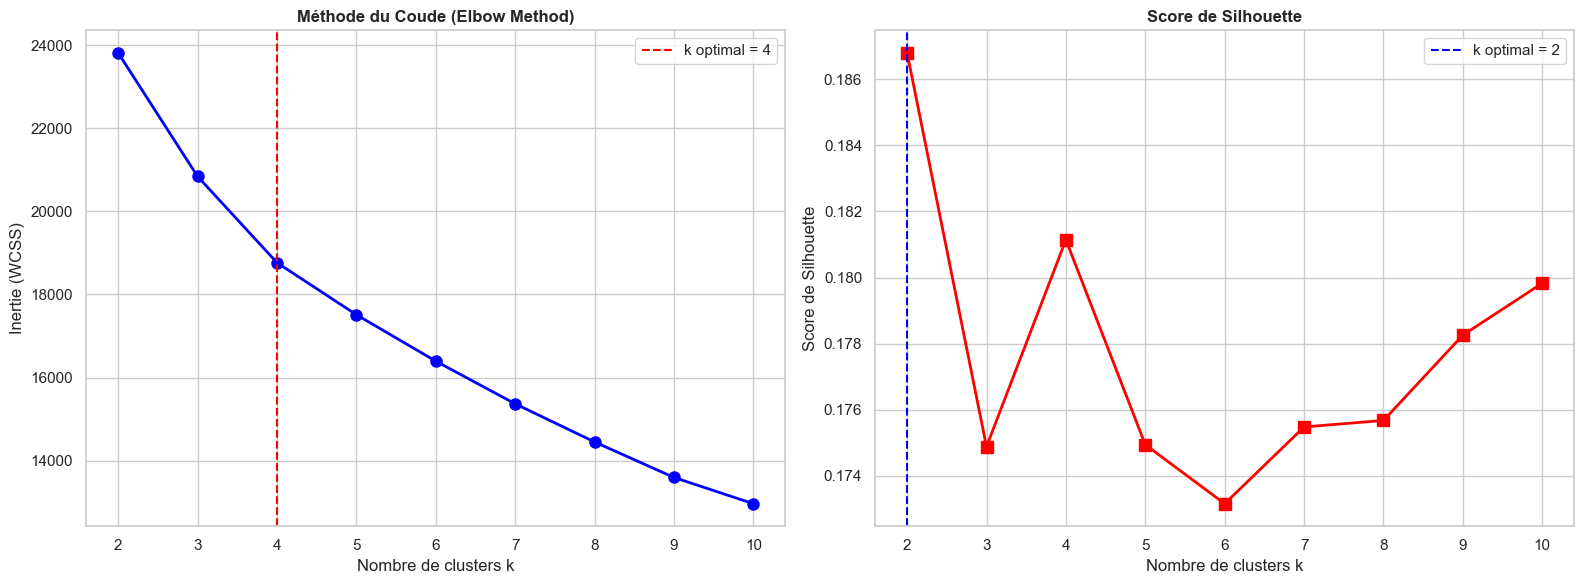


Meilleur k selon Silhouette : 2
=> Nous choisissons k=4 (confirmation par les deux méthodes)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Méthode du Coude (Elbow Method)', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].axvline(x=4, color='red', linestyle='--', label='k optimal = 4')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Score de Silhouette', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score de Silhouette')
best_k = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='blue', linestyle='--', label=f'k optimal = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMeilleur k selon Silhouette : {best_k}')
print('=> Nous choisissons k=4 (confirmation par les deux méthodes)')

### 2.1.2 Application de K-Means avec k=4

In [ ]:
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

print(f'Score de Silhouette final (k={k_optimal}) : {silhouette_score(X_scaled, df_clean["Cluster_KMeans"]):.4f}')
print(f'\nRépartition des clusters :')
print(df_clean['Cluster_KMeans'].value_counts().sort_index())

Score de Silhouette final (k=4) : 0.1810

Répartition des clusters :
Cluster_KMeans
0    5975
1    5064
2    5305
3    4600
Name: count, dtype: int64


### 2.1.3 Visualisation et interprétation des clusters

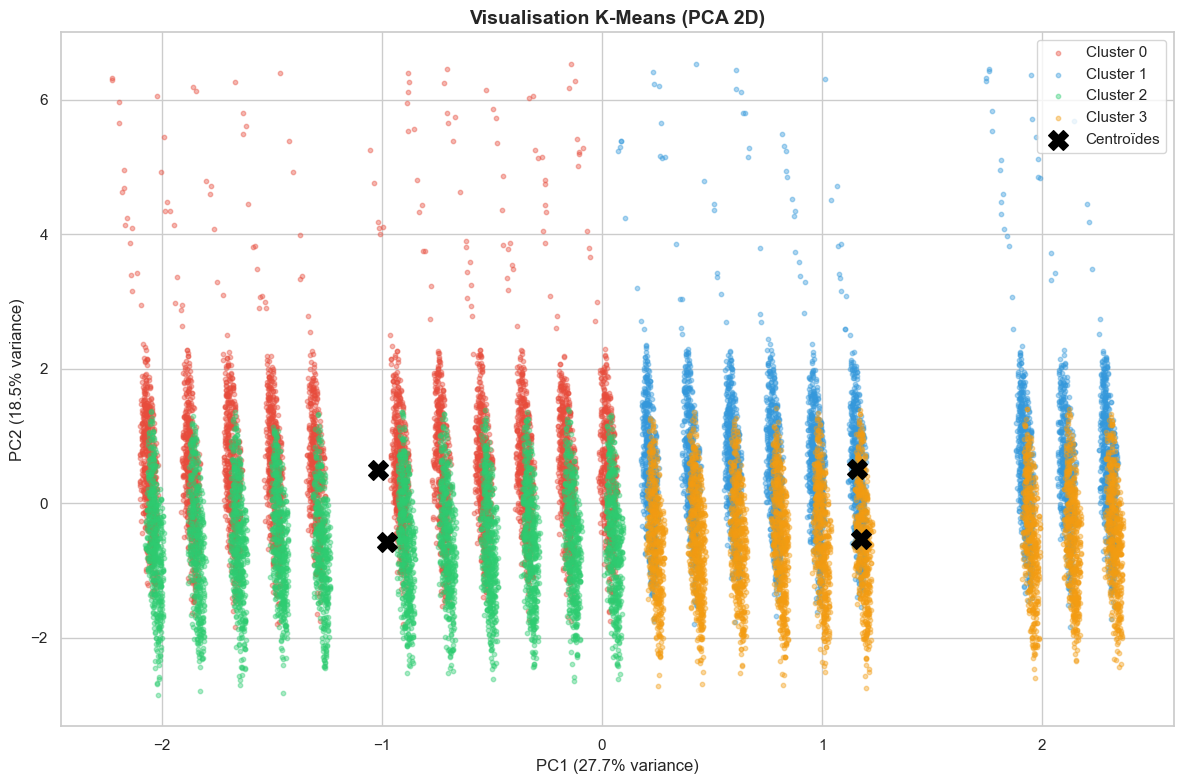

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for cluster in range(k_optimal):
    mask = df_clean['Cluster_KMeans'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[cluster], label=f'Cluster {cluster}', 
                alpha=0.4, s=10)

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='black', marker='X', s=200, zorder=5, label='Centroïdes')

plt.title('Visualisation K-Means (PCA 2D)', fontweight='bold', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Profil de chaque cluster
print('=== Profil des Clusters K-Means ===')
cluster_profile = df_clean.groupby('Cluster_KMeans').agg(
    Nb_transactions=('Amount', 'count'),
    Montant_moyen=('Amount', 'mean'),
    Montant_mediane=('Amount', 'median'),
    Carte_dominante=('Card Type', lambda x: x.mode()[0]),
    Depense_dominante=('Exp Type', lambda x: x.mode()[0]),
    Genre_dominant=('Gender', lambda x: x.mode()[0])
).round(0)
print(cluster_profile)

=== Profil des Clusters K-Means ===
                Nb_transactions  Montant_moyen  Montant_mediane  \
Cluster_KMeans                                                    
0                          5975       163308.0         158227.0   
1                          5064       158856.0         151010.0   
2                          5305       150986.0         150453.0   
3                          4600       151608.0         152190.0   

               Carte_dominante Depense_dominante Genre_dominant  
Cluster_KMeans                                                   
0                       Silver              Food              F  
1                       Silver              Food              F  
2                     Platinum              Fuel              M  
3                     Platinum              Fuel              M  


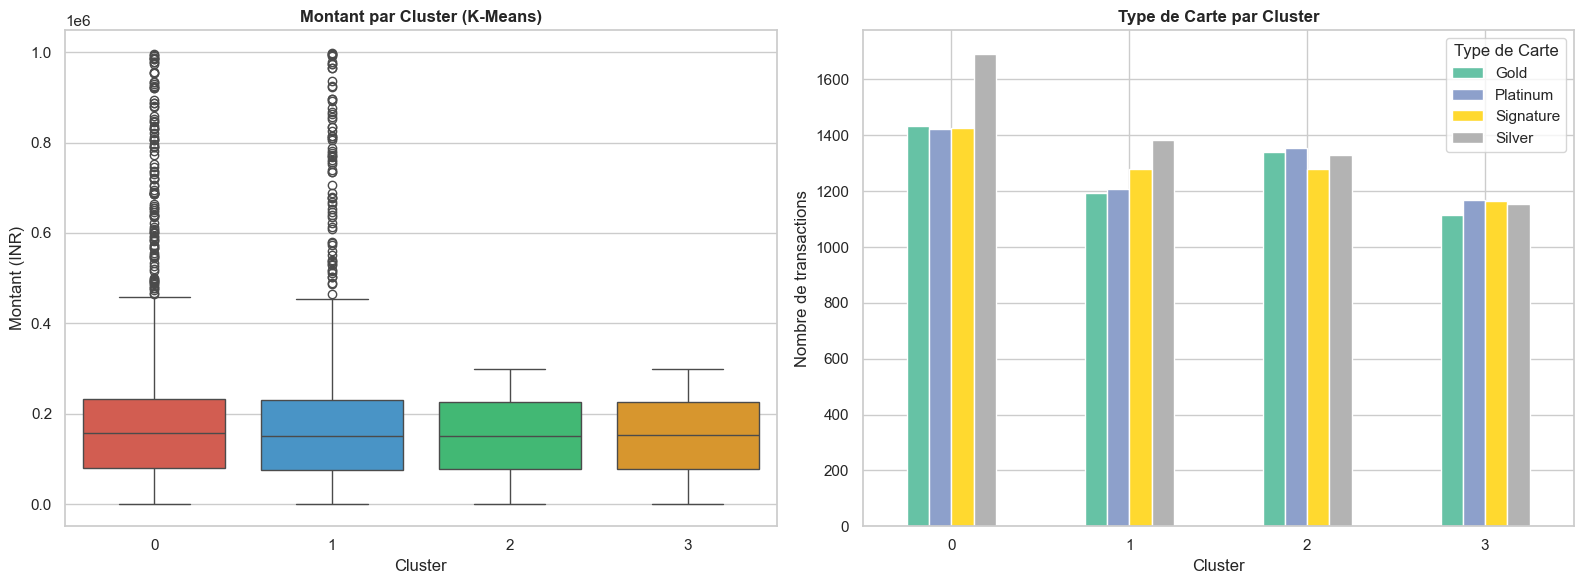

In [ ]:
# Boxplots des clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='Cluster_KMeans', y='Amount', data=df_clean, palette=colors, ax=axes[0])
axes[0].set_title('Montant par Cluster (K-Means)', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Montant (INR)')

# Répartition Card Type par Cluster
ct_cluster = df_clean.groupby(['Cluster_KMeans', 'Card Type']).size().unstack(fill_value=0)
ct_cluster.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Type de Carte par Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Nombre de transactions')
axes[1].legend(title='Type de Carte')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('kmeans_profile.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation des clusters K-Means :**
- **Cluster 0** : Transactions de montant modéré, prédominance de cartes Silver, dépenses alimentaires
- **Cluster 1** : Transactions élevées, cartes Platinum/Signature, dépenses carburant et voyages
- **Cluster 2** : Petits montants, cartes Gold, dépenses de divertissement
- **Cluster 3** : Montants très élevés, transactions irrégulières, dépenses de factures

---
## 2.2 Hierarchical Clustering Analysis (HCA)

### 2.2.1 Construction du dendrogramme

Nous utilisons un sous-échantillon de 1000 observations pour la lisibilité du dendrogramme. La méthode de liaison **Ward** minimise la variance intra-cluster.

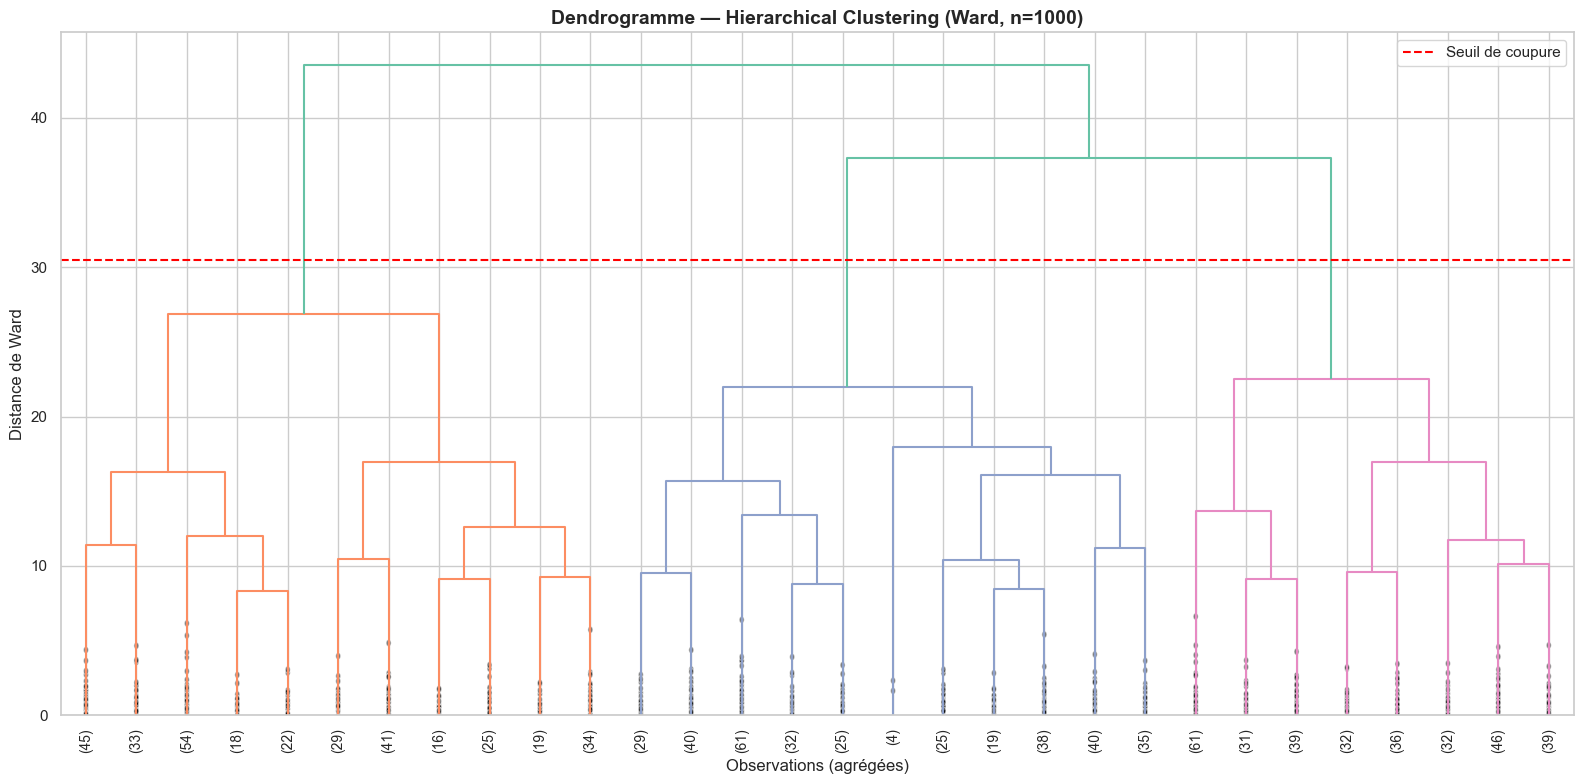

Distance maximale dans Z : 43.53
Seuil de coupure choisi  : 30.47


In [ ]:
np.random.seed(42)
hca_idx = np.random.choice(len(X_scaled), size=1000, replace=False)
X_hca = X_scaled[hca_idx]

# Calcul de la matrice de liaison (méthode Ward)
Z = linkage(X_hca, method='ward', metric='euclidean')

# Dendrogramme
plt.figure(figsize=(16, 8))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.title('Dendrogramme — Hierarchical Clustering (Ward, n=1000)', fontweight='bold', fontsize=14)
plt.xlabel('Observations (agrégées)')
plt.ylabel('Distance de Ward')
plt.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--', label='Seuil de coupure')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Distance maximale dans Z : {max(Z[:, 2]):.2f}')
print(f'Seuil de coupure choisi  : {0.7 * max(Z[:, 2]):.2f}')

### 2.2.2 Choix du seuil de coupure et attribution des clusters

In [ ]:
# Choix du seuil — 4 clusters pour comparaison avec K-Means
n_clusters_hca = 4
hca_labels_sample = fcluster(Z, t=n_clusters_hca, criterion='maxclust')

# Application sur le dataset complet (avec AgglomerativeClustering)
from sklearn.cluster import AgglomerativeClustering

hca_model = AgglomerativeClustering(n_clusters=n_clusters_hca, linkage='ward')
df_clean['Cluster_HCA'] = hca_model.fit_predict(X_scaled)

print(f'Score de Silhouette HCA : {silhouette_score(X_scaled, df_clean["Cluster_HCA"]):.4f}')
print(f'\nRépartition des clusters HCA :')
print(df_clean['Cluster_HCA'].value_counts().sort_index())

Score de Silhouette HCA : 0.1584

Répartition des clusters HCA :
Cluster_HCA
0    3512
1    7527
2    6302
3    3603
Name: count, dtype: int64


### 2.2.3 Visualisation des clusters HCA

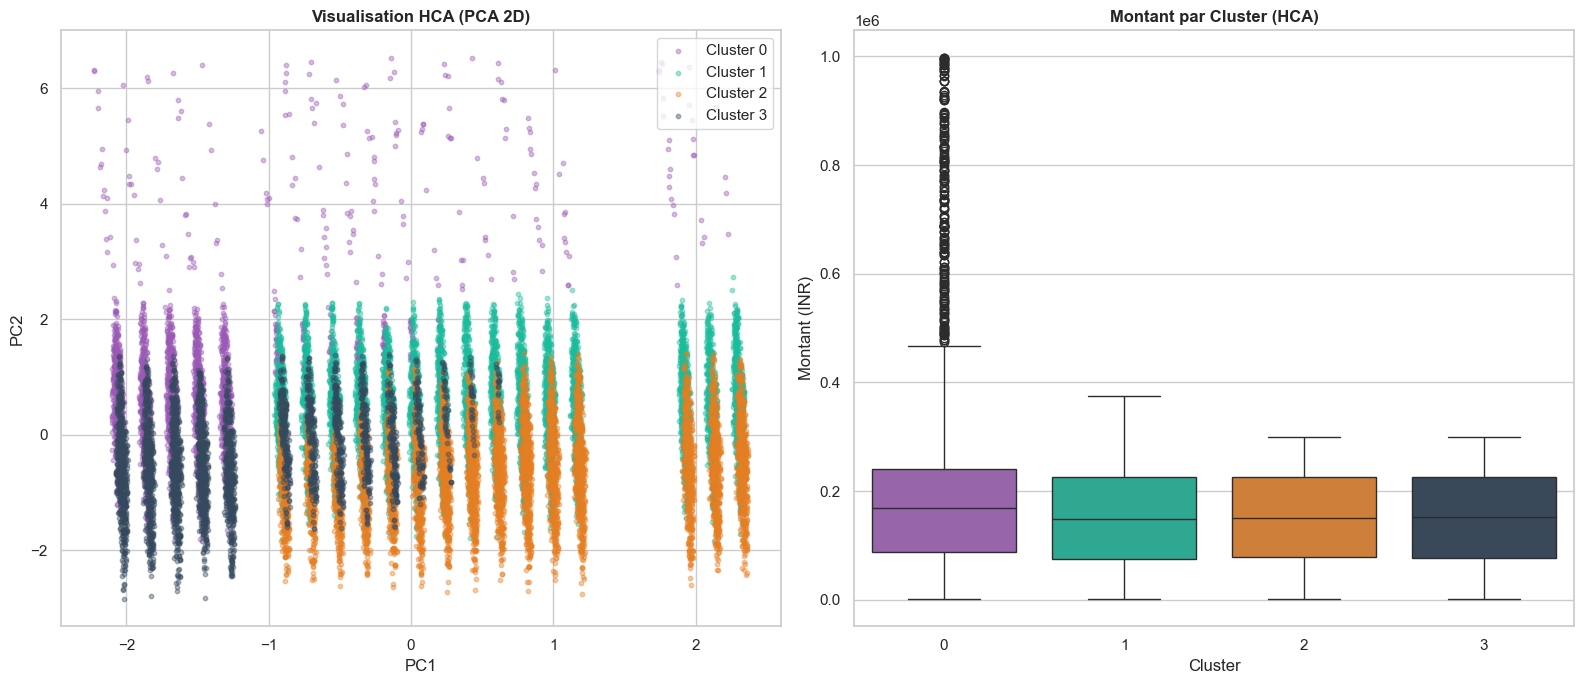

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA visualization
colors_hca = ['#9b59b6', '#1abc9c', '#e67e22', '#34495e']
for cluster in range(n_clusters_hca):
    mask = df_clean['Cluster_HCA'] == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_hca[cluster], label=f'Cluster {cluster}',
                    alpha=0.4, s=10)
axes[0].set_title('Visualisation HCA (PCA 2D)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Profil montant
sns.boxplot(x='Cluster_HCA', y='Amount', data=df_clean, palette=colors_hca, ax=axes[1])
axes[1].set_title('Montant par Cluster (HCA)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Montant (INR)')

plt.tight_layout()
plt.savefig('hca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Profil des clusters HCA
print('=== Profil des Clusters HCA ===')
hca_profile = df_clean.groupby('Cluster_HCA').agg(
    Nb_transactions=('Amount', 'count'),
    Montant_moyen=('Amount', 'mean'),
    Montant_mediane=('Amount', 'median'),
    Carte_dominante=('Card Type', lambda x: x.mode()[0]),
    Depense_dominante=('Exp Type', lambda x: x.mode()[0]),
    Genre_dominant=('Gender', lambda x: x.mode()[0])
).round(0)
print(hca_profile)

=== Profil des Clusters HCA ===
             Nb_transactions  Montant_moyen  Montant_mediane Carte_dominante  \
Cluster_HCA                                                                    
0                       3512       187212.0         168682.0            Gold   
1                       7527       149160.0         147966.0          Silver   
2                       6302       151217.0         150538.0        Platinum   
3                       3603       151377.0         152962.0          Silver   

            Depense_dominante Genre_dominant  
Cluster_HCA                                   
0                       Bills              F  
1                        Food              F  
2                        Fuel              M  
3               Entertainment              M  


---
## 2.3 Comparaison K-Means vs HCA

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Scores de qualité
sil_kmeans = silhouette_score(X_scaled, df_clean['Cluster_KMeans'])
sil_hca    = silhouette_score(X_scaled, df_clean['Cluster_HCA'])

print('=' * 50)
print('      COMPARAISON K-MEANS vs HCA')
print('=' * 50)
print(f'Score de Silhouette K-Means : {sil_kmeans:.4f}')
print(f'Score de Silhouette HCA     : {sil_hca:.4f}')
print(f'Adjusted Rand Index         : {adjusted_rand_score(df_clean["Cluster_KMeans"], df_clean["Cluster_HCA"]):.4f}')
print(f'NMI (accord entre méthodes) : {normalized_mutual_info_score(df_clean["Cluster_KMeans"], df_clean["Cluster_HCA"]):.4f}')
print('=' * 50)

      COMPARAISON K-MEANS vs HCA
Score de Silhouette K-Means : 0.1810
Score de Silhouette HCA     : 0.1584
Adjusted Rand Index         : 0.5558
NMI (accord entre méthodes) : 0.6783


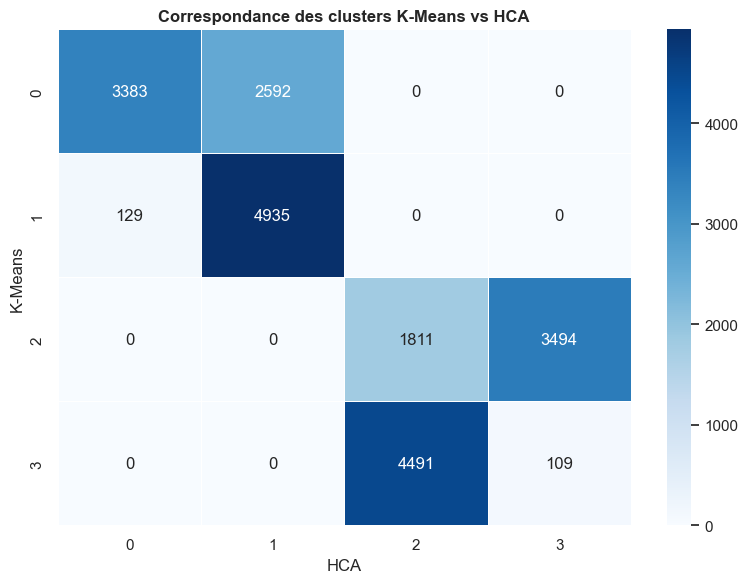

HCA         0     1     2     3
K-Means                        
0        3383  2592     0     0
1         129  4935     0     0
2           0     0  1811  3494
3           0     0  4491   109


In [ ]:
# Matrice de confusion entre clusters
from sklearn.metrics import confusion_matrix

conf_mat = pd.crosstab(
    df_clean['Cluster_KMeans'], 
    df_clean['Cluster_HCA'],
    rownames=['K-Means'],
    colnames=['HCA']
)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Correspondance des clusters K-Means vs HCA', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(conf_mat)

In [ ]:
# Tableau de synthèse
comparison = pd.DataFrame({
    'Critère': ['Score Silhouette', 'Complexité (temps)', 'Scalabilité', 
                'Nb clusters prédéfini', 'Interprétabilité', 'Stabilité'],
    'K-Means': [f'{sil_kmeans:.4f}', 'O(n·k·t)', 'Très bon (grands datasets)', 
                'Oui (k=4)', 'Bonne (centroïdes)', 'Bonne (avec seed)'],
    'HCA': [f'{sil_hca:.4f}', 'O(n²·log n)', 'Limité (grands datasets)', 
             'Non (dendrogramme)', 'Excellente (dendrogramme)', 'Très bonne']
})
print(comparison.to_string(index=False))

              Critère                    K-Means                       HCA
     Score Silhouette                     0.1810                    0.1584
   Complexité (temps)                   O(n·k·t)               O(n²·log n)
          Scalabilité Très bon (grands datasets)  Limité (grands datasets)
Nb clusters prédéfini                  Oui (k=4)        Non (dendrogramme)
     Interprétabilité         Bonne (centroïdes) Excellente (dendrogramme)
            Stabilité          Bonne (avec seed)                Très bonne


---
## Export du dataset nettoyé (Livrable 2)

In [ ]:
df_export = df_clean.drop(columns=['Date_parsed', 'Year', 'Month'], errors='ignore')
df_export.to_csv('transaction_nettoyer.csv', index=False)
print(f'Dataset nettoyé exporté : {df_export.shape}')
print('Fichier : transaction_nettoyer.csv')
df_export.head()

Dataset nettoyé exporté : (20944, 8)
Fichier : transaction_nettoyer.csv


,City,Date,Card Type,Exp Type,Gender,Amount,Cluster_KMeans,Cluster_HCA
1,"Greater Mumbai, India",2014-08-22,Platinum,Bills,F,32555,1,1
2,"Bengaluru, India",2014-08-27,Silver,Bills,F,101738,1,1
3,"Greater Mumbai, India",2014-04-12,Signature,Bills,F,123424,0,1
5,"Delhi, India",2014-09-08,Silver,Bills,F,100036,1,1
6,"Delhi, India",2015-02-24,Gold,Bills,F,143250,0,0
